# 模块十二：计算机视觉
## 12.2 目标检测

> **课时安排**：约2课时  
> **学习目标**：
> - 理解目标检测任务的定义和挑战
> - 掌握边界框（Bounding Box）的不同表示方法
> - 理解锚框（Anchor Box）和非极大值抑制（NMS）的原理
> - 掌握IoU和mAP等核心评估指标
> - 了解两阶段检测器和单阶段检测器的发展脉络
> - 深入理解YOLO的核心思想
> - 能够使用预训练模型进行目标检测

---

## 一、目标检测任务定义

### 1.1 什么是目标检测？

**目标检测**（Object Detection）需要同时回答两个问题：

| 问题 | 任务 | 输出 |
|------|------|------|
| **是什么？** | 分类（Classification） | 物体类别标签 |
| **在哪里？** | 定位（Localization） | 边界框坐标 |

因此，目标检测 = **分类 + 定位**

对图像中的**每个目标**，输出：
1. **类别**（class label）
2. **边界框**（bounding box）
3. **置信度**（confidence score）

### 1.2 目标检测的挑战

- **尺度变化**：同一类别的物体可能大小差异巨大（远处的车 vs 近处的车）
- **遮挡**：物体可能被其他物体部分遮挡
- **密集物体**：场景中可能有大量重叠的物体
- **光照变化**：不同光照条件下物体的外观差异
- **类别不均衡**：某些类别的物体远多于其他类别
- **实时性要求**：实际应用（如自动驾驶）对速度有严格要求

---

## 二、边界框（Bounding Box）表示

### 2.1 四种常见格式

给定一个边界框，有以下四种常见的坐标表示方式：

**1. xyxy格式**（左上角+右下角）：
$$b = (x_{min},\; y_{min},\; x_{max},\; y_{max})$$

**2. xywh格式**（左上角+宽高）：
$$b = (x_{min},\; y_{min},\; w,\; h)$$

**3. cxcywh格式**（中心点+宽高，YOLO使用）：
$$b = (c_x,\; c_y,\; w,\; h)$$

**4. xyah格式**（中心点+宽高+角度，旋转目标检测）：
$$b = (c_x,\; c_y,\; w,\; h,\; \theta)$$

### 2.2 格式转换

各格式之间的转换关系：

$$x_{min} = c_x - \frac{w}{2}, \quad y_{min} = c_y - \frac{h}{2}$$
$$x_{max} = c_x + \frac{w}{2}, \quad y_{max} = c_y + \frac{h}{2}$$

=== 边界框格式转换演示 ===
原始 xyxy:     [50, 80, 200, 250]
转换为 xywh:   [50, 80, 150, 170]
转换为 cxcywh: [125.0, 165.0, 150.0, 170.0]
转回 xyxy:     [50.0, 80.0, 200.0, 250.0]

验证转换正确性: True


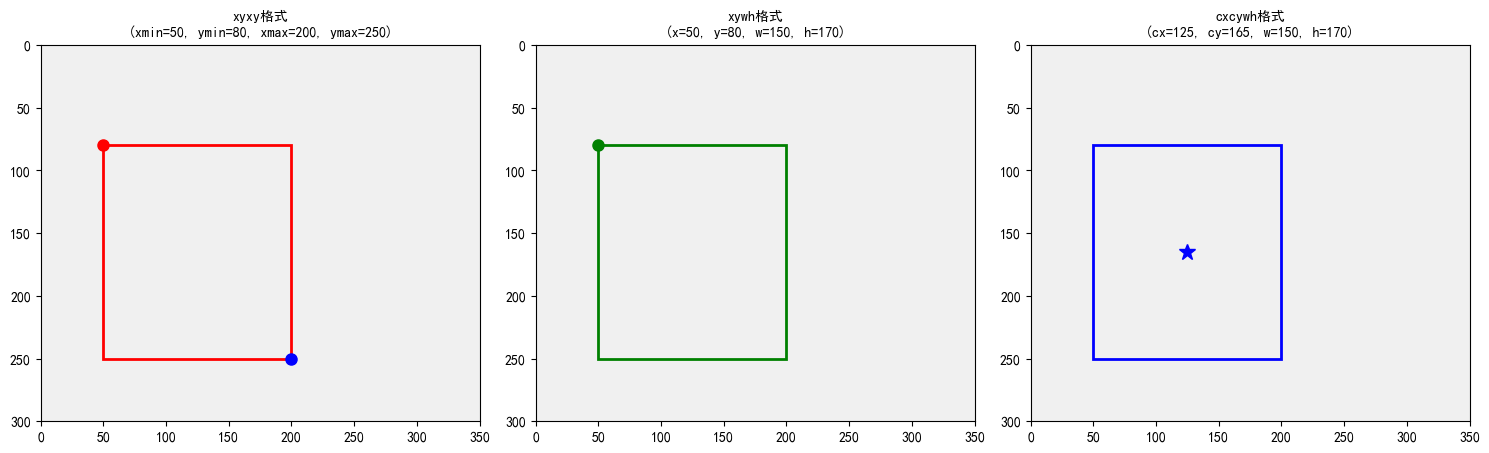

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体（如需其他中文字体可更换）
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

# ============================================================
# 边界框格式转换工具函数
# ============================================================

def xyxy_to_xywh(box):
    """xyxy -> xywh 转换"""
    x1, y1, x2, y2 = box
    return [x1, y1, x2 - x1, y2 - y1]

def xywh_to_xyxy(box):
    """xywh -> xyxy 转换"""
    x, y, w, h = box
    return [x, x + w, y, y + h]

def xyxy_to_cxcywh(box):
    """xyxy -> cxcywh 转换"""
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    cx, cy = x1 + w / 2, y1 + h / 2
    return [cx, cy, w, h]

def cxcywh_to_xyxy(box):
    """cxcywh -> xyxy 转换"""
    cx, cy, w, h = box
    return [cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2]

# 演示转换
box_xyxy = [50, 80, 200, 250]  # (xmin, ymin, xmax, ymax)

box_xywh = xyxy_to_xywh(box_xyxy)
box_cxcywh = xyxy_to_cxcywh(box_xyxy)
box_back = cxcywh_to_xyxy(box_cxcywh)

print("=== 边界框格式转换演示 ===")
print(f"原始 xyxy:     [{box_xyxy[0]}, {box_xyxy[1]}, {box_xyxy[2]}, {box_xyxy[3]}]")
print(f"转换为 xywh:   [{box_xywh[0]}, {box_xywh[1]}, {box_xywh[2]}, {box_xywh[3]}]")
print(f"转换为 cxcywh: [{box_cxcywh[0]:.1f}, {box_cxcywh[1]:.1f}, {box_cxcywh[2]:.1f}, {box_cxcywh[3]:.1f}]")
print(f"转回 xyxy:     [{box_back[0]:.1f}, {box_back[1]:.1f}, {box_back[2]:.1f}, {box_back[3]:.1f}]")
print(f"\n验证转换正确性: {np.allclose(box_xyxy, box_back)}")

# 可视化边界框
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 创建示例图像背景
img_demo = np.ones((300, 350, 3), dtype=np.uint8) * 240

# 1. xyxy格式可视化
ax = axes[0]
ax.imshow(img_demo)
ax.set_title(f'xyxy格式\n(xmin={box_xyxy[0]}, ymin={box_xyxy[1]}, xmax={box_xyxy[2]}, ymax={box_xyxy[3]})', fontsize=10)
rect = patches.Rectangle((box_xyxy[0], box_xyxy[1]), box_xyxy[2]-box_xyxy[0], box_xyxy[3]-box_xyxy[1],
                          linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(rect)
ax.plot(box_xyxy[0], box_xyxy[1], 'ro', markersize=8)
ax.plot(box_xyxy[2], box_xyxy[3], 'bo', markersize=8)

# 2. xywh格式可视化
ax = axes[1]
ax.imshow(img_demo)
ax.set_title(f'xywh格式\n(x={box_xywh[0]}, y={box_xywh[1]}, w={box_xywh[2]}, h={box_xywh[3]})', fontsize=10)
rect = patches.Rectangle((box_xywh[0], box_xywh[1]), box_xywh[2], box_xywh[3],
                          linewidth=2, edgecolor='green', facecolor='none')
ax.add_patch(rect)
ax.plot(box_xywh[0], box_xywh[1], 'go', markersize=8)

# 3. cxcywh格式可视化
ax = axes[2]
ax.imshow(img_demo)
ax.set_title(f'cxcywh格式\n(cx={box_cxcywh[0]:.0f}, cy={box_cxcywh[1]:.0f}, w={box_cxcywh[2]:.0f}, h={box_cxcywh[3]:.0f})', fontsize=10)
rect = patches.Rectangle((box_cxcywh[0]-box_cxcywh[2]/2, box_cxcywh[1]-box_cxcywh[3]/2),
                          box_cxcywh[2], box_cxcywh[3],
                          linewidth=2, edgecolor='blue', facecolor='none')
ax.add_patch(rect)
ax.plot(box_cxcywh[0], box_cxcywh[1], 'b*', markersize=12)

for ax in axes:
    ax.set_xlim(0, 350)
    ax.set_ylim(300, 0)

plt.tight_layout()
plt.show()


---

## 三、锚框（Anchor Box）

### 3.1 为什么需要锚框？

目标检测模型需要预测边界框的位置和大小。如果直接从零开始预测，模型收敛困难。**锚框（Anchor Box）** 提供了一组**预设的参考框**，模型只需要学习"偏移量"。

### 3.2 锚框的设计

在每个网格位置，放置 $k$ 个不同**尺度**和**宽高比**的锚框：

$$\text{锚框集合} = \{A_1, A_2, \ldots, A_k\}$$

例如 Faster R-CNN 在每个位置放置 9 个锚框（3种尺度 × 3种宽高比）：

| 宽高比 | 尺度128 | 尺度256 | 尺度512 |
|--------|---------|---------|---------|
| 1:1 | 128×128 | 256×256 | 512×512 |
| 1:2 | 128×256 | 256×512 | 512×1024 |
| 2:1 | 256×128 | 512×256 | 1024×512 |

### 3.3 锚框与GT的匹配

锚框需要与真实框（Ground Truth）进行匹配，常用的匹配策略：

1. **基于IoU阈值匹配**：IoU > 0.7 为正样本，IoU < 0.3 为负样本
2. **最佳匹配**：每个GT框匹配IoU最大的锚框

特征图尺寸: (7, 7)
锚框数量: 294 (= 7×7×2×3)

前6个锚框 (cx, cy, w, h):
  锚框1: [8.0, 8.0, 11.3, 22.6]
  锚框2: [8.0, 8.0, 16.0, 16.0]
  锚框3: [8.0, 8.0, 22.6, 11.3]
  锚框4: [8.0, 8.0, 22.6, 45.3]
  锚框5: [8.0, 8.0, 32.0, 32.0]
  锚框6: [8.0, 8.0, 45.3, 22.6]


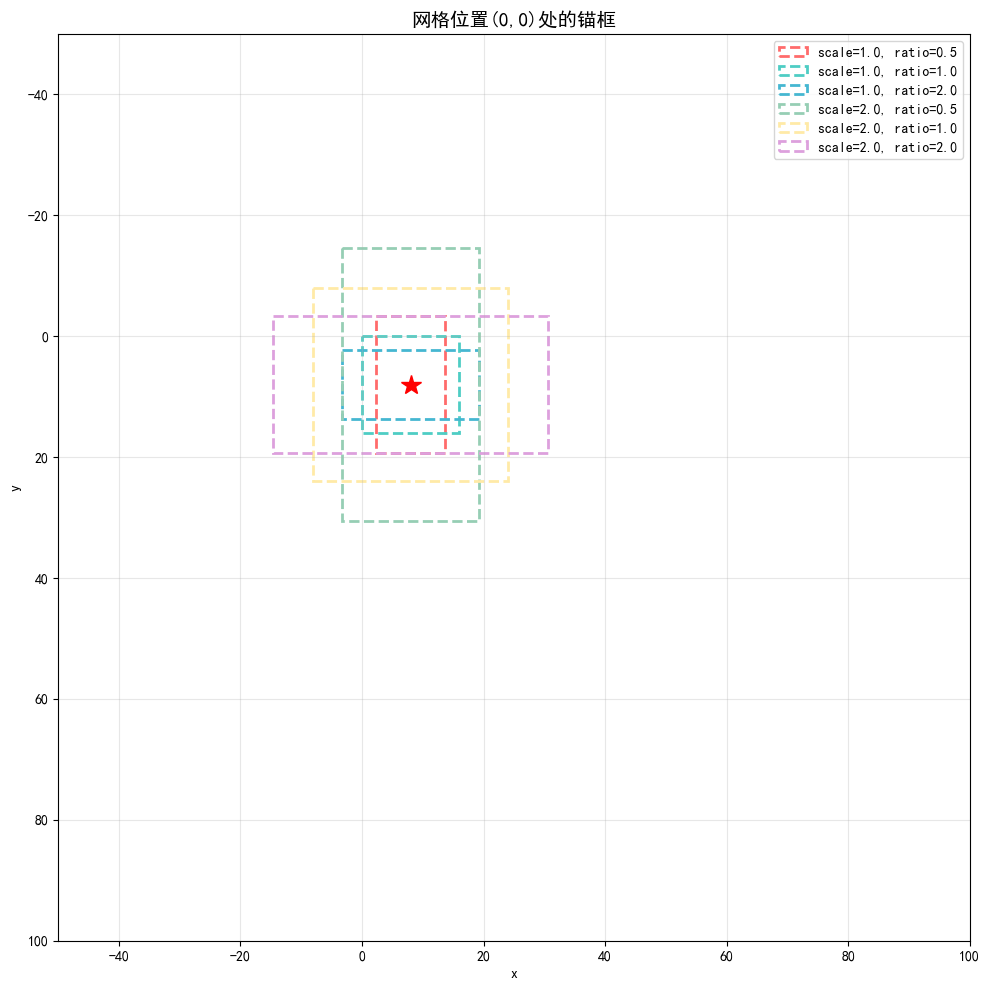

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def generate_anchors(feature_map_size, scales, ratios, base_size=16):
    """
    生成锚框
    
    参数:
        feature_map_size: 特征图尺寸 (h, w)
        scales: 缩放比例列表
        ratios: 宽高比列表
        base_size: 基础框大小（对应特征图上一个像素的感知野）
    
    返回:
        anchors: (N, 4) 的锚框坐标 [cx, cy, w, h]
    """
    fh, fw = feature_map_size
    anchors = []
    
    for y in range(fh):
        for x in range(fw):
            cx = x * base_size + base_size / 2
            cy = y * base_size + base_size / 2
            
            for scale in scales:
                for ratio in ratios:
                    # 计算锚框的宽和高
                    w = base_size * scale * np.sqrt(ratio)
                    h = base_size * scale / np.sqrt(ratio)
                    anchors.append([cx, cy, w, h])
    
    return np.array(anchors)

# 生成锚框
feature_map_size = (7, 7)
scales = [1.0, 2.0]       # 两种尺度
ratios = [0.5, 1.0, 2.0]  # 三种宽高比

anchors = generate_anchors(feature_map_size, scales, ratios)
print(f"特征图尺寸: {feature_map_size}")
print(f"锚框数量: {len(anchors)} (= {feature_map_size[0]}×{feature_map_size[1]}×{len(scales)}×{len(ratios)})")
print(f"\n前6个锚框 (cx, cy, w, h):")
for i in range(min(6, len(anchors))):
    print(f"  锚框{i+1}: [{anchors[i][0]:.1f}, {anchors[i][1]:.1f}, {anchors[i][2]:.1f}, {anchors[i][3]:.1f}]")

# 可视化网格位置(0,0)处的锚框
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 在位置(0,0)处绘制6个锚框
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
for i, (scale, ratio) in enumerate([(s, r) for s in scales for r in ratios]):
    w = 16 * scale * np.sqrt(ratio)
    h = 16 * scale / np.sqrt(ratio)
    cx, cy = 8, 8  # 位置(0,0)的中心
    rect = patches.Rectangle((cx - w/2, cy - h/2), w, h,
                            linewidth=2, edgecolor=colors[i],
                            facecolor='none', linestyle='--',
                            label=f'scale={scale}, ratio={ratio}')
    ax.add_patch(rect)

ax.plot(8, 8, 'r*', markersize=15)
ax.set_xlim(-50, 100)
ax.set_ylim(100, -50)
ax.legend(loc='upper right')
ax.set_title('网格位置(0,0)处的锚框', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---

## 四、非极大值抑制（NMS）

### 4.1 为什么需要NMS？

目标检测模型通常会为同一个物体生成**多个重叠的检测框**。我们需要使用**非极大值抑制（Non-Maximum Suppression, NMS）** 来消除冗余检测。

### 4.2 NMS算法流程

```
输入: 所有检测框 B = {b_1, b_2, ..., b_n}，对应置信度 S = {s_1, s_2, ..., s_n}，IoU阈值 T

1. 按置信度降序排列检测框
2. 选取置信度最高的框 b_i，加入输出集合 D
3. 计算其余所有框与 b_i 的IoU
4. 删除 IoU > T 的框（视为对同一物体的重复检测）
5. 重复步骤2-4，直到所有框都被处理
6. 返回 D
```

### 4.3 NMS的改进版本

| 方法 | 思路 |
|------|------|
| **Soft-NMS** | 不是直接删除，而是降低IoU过高的框的置信度 |
| **DIoU-NMS** | 考虑框中心距离，而非仅IoU |
| **Matrix NMS** | 并行化处理，速度更快 |

In [7]:
import numpy as np

def calculate_iou(box1, box2):
    """
    计算两个边界框的IoU（交并比）
    
    参数:
        box1, box2: [x1, y1, x2, y2] 格式
    返回:
        iou: 交并比值
    """
    # 计算交集区域
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])
    
    if x2_inter <= x1_inter or y2_inter <= y1_inter:
        return 0.0
    
    inter_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
    
    # 计算并集区域
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    
    iou = inter_area / union_area
    return iou

def nms(boxes, scores, iou_threshold=0.5):
    """
    非极大值抑制
    
    参数:
        boxes: (N, 4) 边界框 [x1, y1, x2, y2]
        scores: (N,) 每个框的置信度
        iou_threshold: IoU阈值
    
    返回:
        keep: 保留的框的索引
    """
    # 按置信度降序排列
    order = scores.argsort()[::-1]
    keep = []
    
    while len(order) > 0:
        i = order[0]  # 置信度最高的框
        keep.append(i)
        
        # 计算当前框与剩余框的IoU
        remaining = order[1:]
        suppress = []
        
        for j in remaining:
            iou = calculate_iou(boxes[i], boxes[j])
            if iou > iou_threshold:
                suppress.append(j)
        
        # 删除被抑制的框
        order = np.array([j for j in remaining if j not in suppress])
    
    return keep

# ============================================================
# NMS 演示
# ============================================================

# 模拟检测结果：多个重叠的边界框
boxes = np.array([
    [100, 100, 250, 280],   # 框1 (与真实框最接近)
    [110, 105, 260, 290],   # 框2 (与框1高度重叠)
    [95, 95, 240, 270],     # 框3 (与框1高度重叠)
    [300, 150, 450, 350],   # 框4 (另一个物体)
    [310, 160, 460, 360],   # 框5 (与框4重叠)
    [290, 140, 440, 340],   # 框6 (与框4重叠)
], dtype=np.float32)

scores = np.array([0.95, 0.88, 0.82, 0.91, 0.85, 0.78])

# 运行NMS
keep = nms(boxes, scores, iou_threshold=0.5)

print("=== NMS演示 ===")
print(f"输入: {len(boxes)} 个检测框")
print(f"\n所有检测结果:")
for i, (box, score) in enumerate(zip(boxes, scores)):
    print(f"  框{i+1}: {box.tolist()}, 置信度={score:.2f}")

print(f"\nNMS后保留 {len(keep)} 个框:")
for idx in keep:
    print(f"  框{idx+1}: {boxes[idx].tolist()}, 置信度={scores[idx]:.2f}")

# 验证保留框之间的IoU
print(f"\n保留框之间的IoU:")
if len(keep) >= 2:
    iou = calculate_iou(boxes[keep[0]], boxes[keep[1]])
    print(f"  框{keep[0]+1} vs 框{keep[1]+1}: IoU = {iou:.4f}")


=== NMS演示 ===
输入: 6 个检测框

所有检测结果:
  框1: [100.0, 100.0, 250.0, 280.0], 置信度=0.95
  框2: [110.0, 105.0, 260.0, 290.0], 置信度=0.88
  框3: [95.0, 95.0, 240.0, 270.0], 置信度=0.82
  框4: [300.0, 150.0, 450.0, 350.0], 置信度=0.91
  框5: [310.0, 160.0, 460.0, 360.0], 置信度=0.85
  框6: [290.0, 140.0, 440.0, 340.0], 置信度=0.78

NMS后保留 2 个框:
  框1: [100.0, 100.0, 250.0, 280.0], 置信度=0.95
  框4: [300.0, 150.0, 450.0, 350.0], 置信度=0.91

保留框之间的IoU:
  框1 vs 框4: IoU = 0.0000


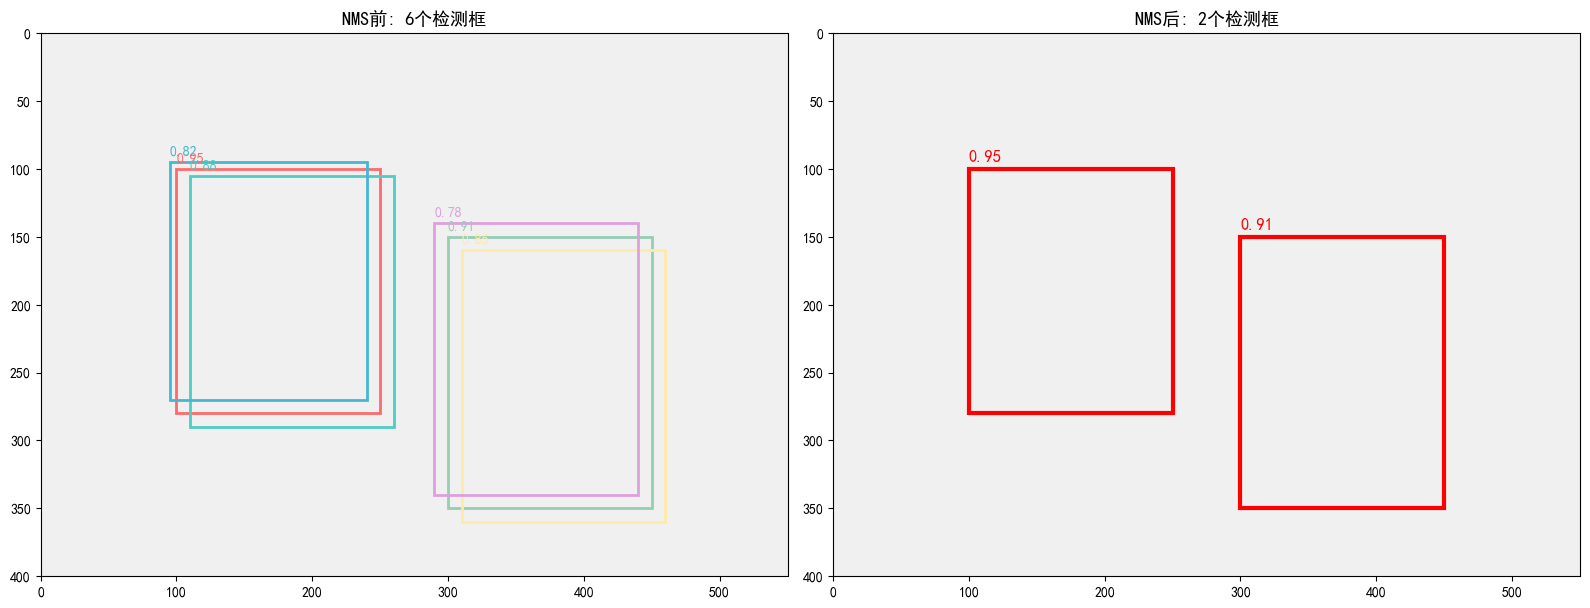

In [8]:
# 可视化NMS效果
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

img_bg = np.ones((400, 550, 3), dtype=np.uint8) * 240

# 左图：NMS前的所有检测框
ax = axes[0]
ax.imshow(img_bg)
ax.set_title(f'NMS前: {len(boxes)}个检测框', fontsize=13)
colors_all = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
for i, (box, score) in enumerate(zip(boxes, scores)):
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                            linewidth=2, edgecolor=colors_all[i],
                            facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1-5, f'{score:.2f}', color=colors_all[i], fontsize=10, fontweight='bold')

# 右图：NMS后保留的检测框
ax = axes[1]
ax.imshow(img_bg)
ax.set_title(f'NMS后: {len(keep)}个检测框', fontsize=13)
for idx in keep:
    box = boxes[idx]
    score = scores[idx]
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                            linewidth=3, edgecolor='red',
                            facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1-5, f'{score:.2f}', color='red', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_xlim(0, 550)
    ax.set_ylim(400, 0)

plt.tight_layout()
plt.show()


---

## 五、评估指标

### 5.1 IoU（Intersection over Union，交并比）

IoU是衡量两个边界框重叠程度的指标：

$$\text{IoU} = \frac{A \cap B}{A \cup B} = \frac{\text{交集面积}}{\text{并集面积}}$$

- IoU ∈ [0, 1]
- IoU = 1：完全重合
- IoU = 0：完全不重叠
- 通常以 **IoU ≥ 0.5** 作为正确检测的标准

### 5.2 精确率-召回率曲线

对于目标检测：

$$\text{Precision} = \frac{TP}{TP + FP} = \frac{\text{正确检测数}}{\text{总检测数}}$$

$$\text{Recall} = \frac{TP}{TP + FN} = \frac{\text{正确检测数}}{\text{总GT数}}$$

其中：
- **TP**（True Positive）：IoU > 阈值 且 类别正确
- **FP**（False Positive）：IoU ≤ 阈值 或 类别错误
- **FN**（False Negative）：未被检测到的GT框

### 5.3 AP（Average Precision）

$$\text{AP} = \int_0^1 P(R)\, dR$$

实际计算中，使用**11点插值法**或**全点插值法**：

$$\text{AP} = \sum_{k=1}^{n} (R_{k+1} - R_k) \cdot P_{interp}(R_{k+1})$$

### 5.4 mAP（mean Average Precision）

$$\text{mAP} = \frac{1}{C} \sum_{c=1}^{C} \text{AP}_c$$

其中 $C$ 是类别总数。

**COCO评估标准**：
- mAP@0.5: IoU阈值为0.5时的mAP
- mAP@0.5:0.95: IoU阈值从0.5到0.95（步长0.05）的mAP的平均值

=== IoU计算示例 ===
框A: [100, 100, 250, 250]
框B: [150, 150, 300, 300]
框C: [300, 300, 400, 400]

IoU(A, B) = 0.2857
IoU(A, C) = 0.0000
IoU(B, C) = 0.0000


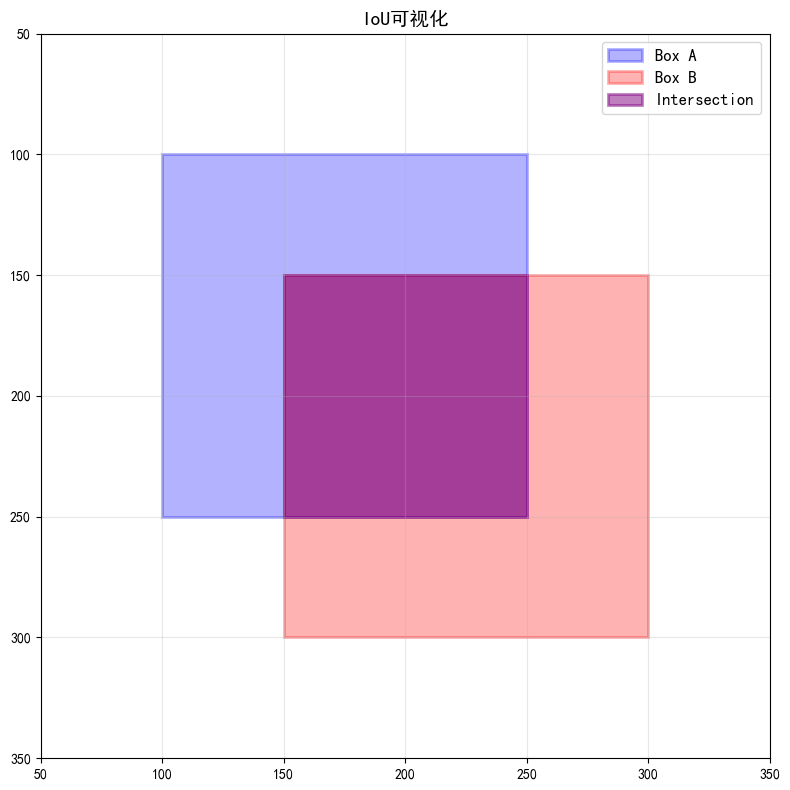


=== AP计算示例 ===
AP (11点插值) = 0.8571


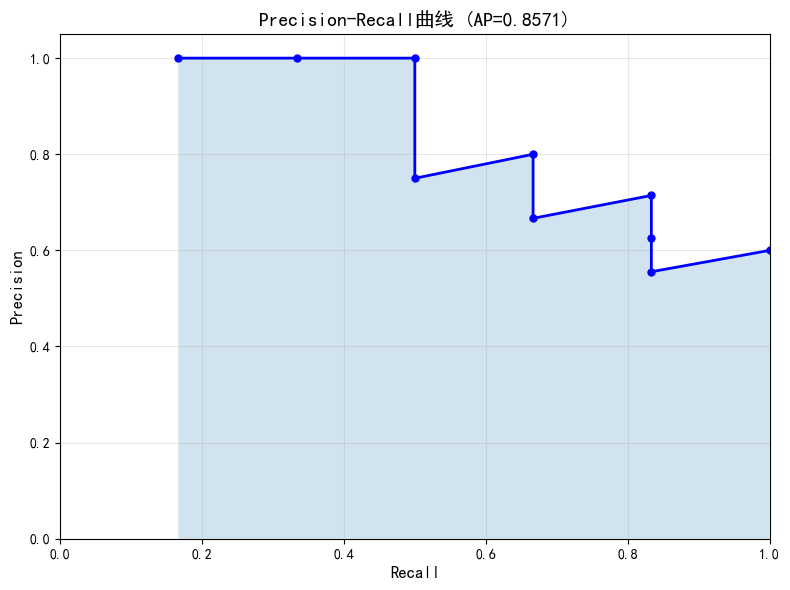

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_iou_batch(boxes1, boxes2):
    """计算两组框之间的IoU矩阵"""
    iou_matrix = np.zeros((len(boxes1), len(boxes2)))
    for i, b1 in enumerate(boxes1):
        for j, b2 in enumerate(boxes2):
            iou_matrix[i, j] = calculate_iou(b1, b2)
    return iou_matrix

# IoU计算示例
box_a = [100, 100, 250, 250]
box_b = [150, 150, 300, 300]
box_c = [300, 300, 400, 400]

print("=== IoU计算示例 ===")
print(f"框A: {box_a}")
print(f"框B: {box_b}")
print(f"框C: {box_c}")
print(f"\nIoU(A, B) = {calculate_iou(box_a, box_b):.4f}")
print(f"IoU(A, C) = {calculate_iou(box_a, box_c):.4f}")
print(f"IoU(B, C) = {calculate_iou(box_b, box_c):.4f}")

# 可视化IoU
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_title('IoU可视化', fontsize=14)

# 画框A和B的重叠
rect_a = patches.Rectangle((100, 100), 150, 150, linewidth=2, 
                            edgecolor='blue', facecolor='blue', alpha=0.3, label='Box A')
rect_b = patches.Rectangle((150, 150), 150, 150, linewidth=2,
                            edgecolor='red', facecolor='red', alpha=0.3, label='Box B')
ax.add_patch(rect_a)
ax.add_patch(rect_b)

# 高亮交集区域
intersection = patches.Rectangle((150, 150), 100, 100, linewidth=2,
                                edgecolor='purple', facecolor='purple', alpha=0.5, label='Intersection')
ax.add_patch(intersection)

ax.legend(fontsize=12)
ax.set_xlim(50, 350)
ax.set_ylim(350, 50)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# AP计算示例
# ============================================================
print("\n=== AP计算示例 ===")

# 模拟一个类别的检测结果
# (置信度, 是否为TP)
detections = [
    (0.99, True),
    (0.95, True),
    (0.90, True),
    (0.85, False),
    (0.80, True),
    (0.75, False),
    (0.70, True),
    (0.65, False),
    (0.60, False),
    (0.55, True),
]

# 计算Precision和Recall
total_gt = 6  # 总共6个GT
cumulative_tp = 0
cumulative_fp = 0
precisions = []
recalls = []

for score, is_tp in detections:
    if is_tp:
        cumulative_tp += 1
    else:
        cumulative_fp += 1
    
    precision = cumulative_tp / (cumulative_tp + cumulative_fp)
    recall = cumulative_tp / total_gt
    precisions.append(precision)
    recalls.append(recall)

# 计算AP (11点插值)
ap_11point = 0
for r_thresh in np.linspace(0, 1, 11):
    p_interp = 0
    for p, r in zip(precisions, recalls):
        if r >= r_thresh:
            p_interp = max(p_interp, p)
    ap_11point += p_interp / 11

print(f"AP (11点插值) = {ap_11point:.4f}")

# 绘制PR曲线
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(recalls, precisions, 'b-o', linewidth=2, markersize=5)
ax.fill_between(recalls, precisions, alpha=0.2)
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title(f'Precision-Recall曲线 (AP={ap_11point:.4f})', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


---

## 六、经典目标检测方法

### 6.1 目标检测方法发展历程

```
2014  R-CNN              → 两阶段检测的开端
2015  Fast R-CNN         → 共享卷积特征
2015  Faster R-CNN       → 引入RPN（区域候选网络）
2016  YOLOv1             → 单阶段检测，速度革命
2016  SSD                → 多尺度特征图检测
2017  YOLOv2/YOLO9000    → 引入Anchor Box
2018  YOLOv3             → 多尺度检测
2020  YOLOv4/v5          → 工程优化巅峰
2023  YOLOv8             → Anchor-Free + 解耦头
```

### 6.2 两阶段检测器（Two-Stage）

**核心思想**：先生成候选区域，再对每个候选区域进行分类和回归。

#### R-CNN (2014)
```
输入图像 → Selective Search（~2000个候选框）→ 
    每个候选框 → CNN特征提取 → SVM分类 + 边界框回归
```
- **问题**：每个候选框独立提取CNN特征，极其缓慢

#### Fast R-CNN (2015)
```
输入图像 → CNN特征图 → RoI Pooling → 全连接层 → 
    分类分支 + 回归分支
```
- **改进**：整张图只做一次CNN，通过RoI Pooling提取区域特征
- **问题**：候选框仍由Selective Search生成，耗时长

#### Faster R-CNN (2015) ⭐
```
输入图像 → Backbone（ResNet）→ 特征图 → 
    RPN（区域候选网络）→ 候选框 → 
    RoI Pooling → 分类 + 回归
```

**RPN（Region Proposal Network）的关键设计**：
1. 在特征图每个位置生成 $k$ 个锚框
2. 对每个锚框预测：是否包含物体（前景/背景）+ 框偏移量
3. 使用NMS过滤冗余候选框
4. 端到端训练，无需外部候选框生成

$$\mathcal{L}_{RPN} = \frac{1}{N_{cls}}\sum_i L_{cls}(p_i, p_i^*) + \lambda \frac{1}{N_{reg}}\sum_i p_i^* L_{reg}(t_i, t_i^*)$$

### 6.3 单阶段检测器（One-Stage）

**核心思想**：直接在特征图上进行分类和回归，无需候选区域。

#### SSD (2016)
```
输入图像 → Backbone → 多尺度特征图 → 
    每个位置: 多个锚框 → 分类 + 回归
```
- 使用多尺度特征图检测不同大小的物体
- 速度快，精度也不错

#### YOLO（You Only Look Once）系列
- **YOLOv1**：将图像划分为 $S \times S$ 网格，每个网格预测 $B$ 个框
- **YOLOv2/v3**：引入Anchor Box、多尺度检测、残差连接
- **YOLOv4/v5**：大量工程优化（CSPDarknet、PANet、SPP等）
- **YOLOv8**：Anchor-Free设计，解耦分类和回归头

---

## 七、YOLO核心思想详解

### 7.1 YOLOv1的核心设计

YOLO（You Only Look Once）将目标检测转化为一个**回归问题**：

$$\text{目标检测} \xrightarrow{\text{YOLO}} \text{网格划分 + 回归预测}$$

#### 网格划分

将输入图像划分为 $S \times S$ 个网格（YOLOv1中 $S=7$）：

```
+-------+-------+-------+-------+-------+-------+-------+
| (0,0) | (1,0) | (2,0) | (3,0) | (4,0) | (5,0) | (6,0) |
+-------+-------+-------+-------+-------+-------+-------+
| (0,1) | (1,1) | (2,1) | (3,1) | (4,1) | (5,1) | (6,1) |
+-------+-------+-------+-------+-------+-------+-------+
|  ...  |  ...  |  ...  |  ...  |  ...  |  ...  |  ...  |
+-------+-------+-------+-------+-------+-------+-------+
```

**规则**：如果某个物体的中心落在网格 $(i, j)$ 中，则该网格负责检测这个物体。

#### 每个网格的预测

YOLOv1中每个网格预测 $B=2$ 个边界框，每个框包含5个值：
$$[x, y, w, h, \text{confidence}]$$

加上 $C$ 个类别概率，每个网格的预测向量长度为：
$$S \times S \times (B \times 5 + C) = 7 \times 7 \times (2 \times 5 + 20) = 7 \times 7 \times 30$$

其中：
- $x, y$：边界框中心相对于网格的偏移
- $w, h$：边界框的宽高（相对于整张图像的比例）
- confidence：置信度 = $\Pr(\text{Object}) \times \text{IoU}_{pred}^{truth}$
- $C$ 个类别概率

#### YOLOv1的损失函数

$$\mathcal{L} = \lambda_{coord}\sum_{i=0}^{S^2}\sum_{j=0}^{B} \mathbb{1}_{ij}^{obj}[(x_i - \hat{x}_i)^2 + (y_i - \hat{y}_i)^2]$$
$$+ \lambda_{coord}\sum_{i=0}^{S^2}\sum_{j=0}^{B} \mathbb{1}_{ij}^{obj}[\sqrt{w_i} - \sqrt{\hat{w}_i})^2 + (\sqrt{h_i} - \sqrt{\hat{h}_i})^2]$$
$$+ \sum_{i=0}^{S^2}\sum_{j=0}^{B} \mathbb{1}_{ij}^{obj}(C_i - \hat{C}_i)^2$$
$$+ \lambda_{noobj}\sum_{i=0}^{S^2}\sum_{j=0}^{B} \mathbb{1}_{ij}^{noobj}(C_i - \hat{C}_i)^2$$
$$+ \sum_{i=0}^{S^2} \mathbb{1}_{i}^{obj}\sum_{c \in classes}(p_i(c) - \hat{p}_i(c))^2$$

C:\Users\Terry\AppData\Local\Temp\ipykernel_29056\1677841819.py:73: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from current font.
  plt.tight_layout()
C:\Users\Terry\AppData\Local\Temp\ipykernel_29056\1677841819.py:73: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from current font.
  plt.tight_layout()
C:\Users\Terry\AppData\Local\Temp\ipykernel_29056\1677841819.py:73: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  plt.tight_layout()
C:\Users\Terry\AppData\Local\Temp\ipykernel_29056\1677841819.py:73: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from current font.
  plt.tight_layout()
C:\Users\Terry\AppData\Local\Temp\ipykernel_29056\1677841819.py:73: UserWarning: Glyph 21367 (\N{CJK UNIFIED IDEOGRAPH-5377}) missing from current font.
  plt.tight_layout()
C:\Users\Terry\AppData\Local\Temp\ipykernel_29056\1677841819.py:73: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) miss

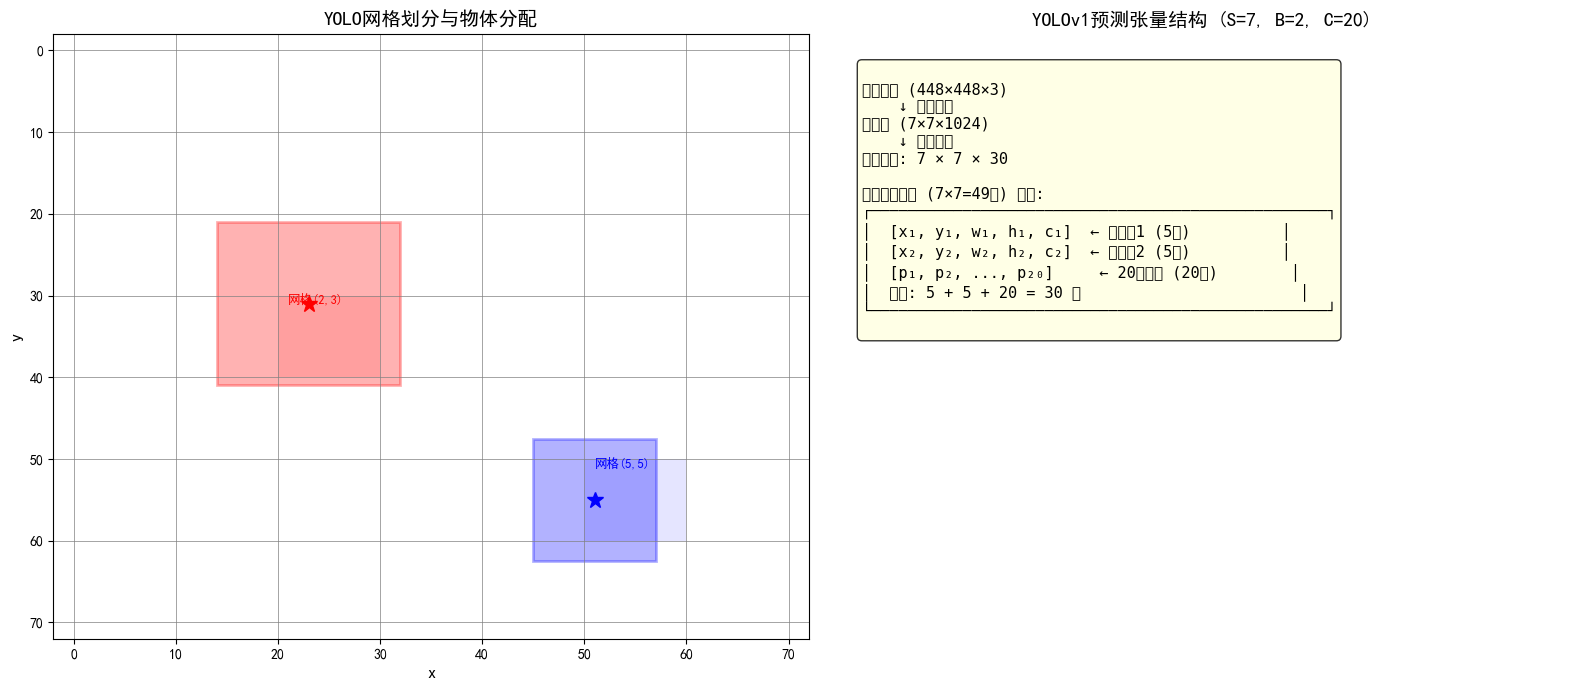

YOLO核心思想：将图像划分为S×S网格，每个网格直接回归出边界框和类别概率
优势：速度快（单次前向传播完成检测），全局推理能力强
劣势：小物体和密集物体检测能力相对较弱


In [10]:
# ============================================================
# YOLO网格划分可视化
# ============================================================
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 左图：网格划分 + 物体分配
ax = axes[0]
ax.set_title('YOLO网格划分与物体分配', fontsize=14)

S = 7  # 网格大小
cell_size = 10

# 画网格
for i in range(S + 1):
    ax.axhline(y=i * cell_size, color='gray', linewidth=0.5)
    ax.axvline(x=i * cell_size, color='gray', linewidth=0.5)

# 模拟两个物体
# 物体1：中心在(2.3, 3.1) → 落在网格(2, 3)
cx1, cy1 = 2.3 * cell_size, 3.1 * cell_size
w1, h1 = 1.8 * cell_size, 2.0 * cell_size
rect1 = patches.Rectangle((cx1 - w1/2, cy1 - h1/2), w1, h1,
                          linewidth=2, edgecolor='red', facecolor='red', alpha=0.3)
ax.add_patch(rect1)
ax.plot(cx1, cy1, 'r*', markersize=12)
ax.text(2 * cell_size + 1, 3 * cell_size + 1, '网格(2,3)', color='red', fontsize=9, fontweight='bold')
ax.add_patch(patches.Rectangle((2 * cell_size, 3 * cell_size), cell_size, cell_size,
                                linewidth=0, facecolor='red', alpha=0.1))

# 物体2：中心在(5.1, 5.5) → 落在网格(5, 5)
cx2, cy2 = 5.1 * cell_size, 5.5 * cell_size
w2, h2 = 1.2 * cell_size, 1.5 * cell_size
rect2 = patches.Rectangle((cx2 - w2/2, cy2 - h2/2), w2, h2,
                          linewidth=2, edgecolor='blue', facecolor='blue', alpha=0.3)
ax.add_patch(rect2)
ax.plot(cx2, cy2, 'b*', markersize=12)
ax.text(5 * cell_size + 1, 5 * cell_size + 1, '网格(5,5)', color='blue', fontsize=9, fontweight='bold')
ax.add_patch(patches.Rectangle((5 * cell_size, 5 * cell_size), cell_size, cell_size,
                                linewidth=0, facecolor='blue', alpha=0.1))

ax.set_xlim(-2, S * cell_size + 2)
ax.set_ylim(S * cell_size + 2, -2)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)

# 右图：预测张量形状
ax = axes[1]
ax.set_title('YOLOv1预测张量结构 (S=7, B=2, C=20)', fontsize=14)
ax.axis('off')

# 绘制张量结构图
tensor_text = """
输入图像 (448×448×3)
    ↓ 卷积网络
特征图 (7×7×1024)
    ↓ 全连接层
预测张量: 7 × 7 × 30

每个网格单元 (7×7=49个) 包含:
┌──────────────────────────────────────────────────┐
│  [x₁, y₁, w₁, h₁, c₁]  ← 边界框1 (5维)          │
│  [x₂, y₂, w₂, h₂, c₂]  ← 边界框2 (5维)          │
│  [p₁, p₂, ..., p₂₀]     ← 20类概率 (20维)        │
│  总计: 5 + 5 + 20 = 30 维                        │
└──────────────────────────────────────────────────┘
"""
ax.text(0.05, 0.95, tensor_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print("YOLO核心思想：将图像划分为S×S网格，每个网格直接回归出边界框和类别概率")
print("优势：速度快（单次前向传播完成检测），全局推理能力强")
print("劣势：小物体和密集物体检测能力相对较弱")


### 7.2 YOLO系列对比

| 版本 | 年份 | 输入尺寸 | 特点 | 速度(FPS) | mAP |
|------|------|---------|------|-----------|-----|
| YOLOv1 | 2016 | 448×448 | 首次提出网格检测 | 45 | 63.4% |
| YOLOv2 | 2017 | 416×416 | Anchor Box + BN | 67 | 78.6% |
| YOLOv3 | 2018 | 416×416 | 多尺度FPN + Darknet-53 | 33 | 57.9% |
| YOLOv4 | 2020 | 416×416 | CSPDarknet + PANet | 65 | 65.7% |
| YOLOv5 | 2020 | 640×640 | PyTorch实现 + 工程优化 | 100+ | 67.2% |
| YOLOv8 | 2023 | 640×640 | Anchor-Free + 解耦头 | 100+ | 53.9% |

> 注意：不同版本使用的评估数据集和指标定义可能不同，mAP值不可直接对比。

### 7.3 两阶段 vs 单阶段对比

| 特性 | 两阶段（Faster R-CNN） | 单阶段（YOLO） |
|------|----------------------|----------------|
| **精度** | 较高 | 略低（但差距在缩小） |
| **速度** | 较慢（5-17 FPS） | 快（30-150+ FPS） |
| **小物体检测** | 较好 | 较弱 |
| **候选框** | RPN生成 | 锚框直接预测 |
| **应用场景** | 精度优先 | 速度优先 |

---

## 八、实战：使用预训练模型进行目标检测

### 8.1 使用torchvision的Faster R-CNN

torchvision提供了预训练的Faster R-CNN模型，可以直接使用COCO数据集的80类标签进行检测。

In [11]:
import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print(f"PyTorch版本: {torch.__version__}")
print(f"torchvision版本: {torchvision.__version__}")

# 加载预训练的Faster R-CNN模型
print("\n正在加载Faster R-CNN模型...")
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()  # 设置为评估模式
print("模型加载完成！")

# COCO数据集的80个类别（索引0为背景）
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A',
    'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
    'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
    'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed',
    'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
    'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
    'hair drier', 'toothbrush'
]

print(f"支持类别数: {len(COCO_CLASSES)} (含背景)")


PyTorch版本: 2.6.0+cpu
torchvision版本: 0.21.0+cpu

正在加载Faster R-CNN模型...


c:\ProgramData\Anaconda3\envs\py311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\ProgramData\Anaconda3\envs\py311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\Terry/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:06<00:00, 27.9MB/s] 

模型加载完成！
支持类别数: 91 (含背景)


In [12]:
# 创建示例图像进行检测（实际使用时可替换为真实图片）
print("创建示例图像...")
# 生成一个带有简单物体形状的图像
img_array = np.random.randint(100, 200, (480, 640, 3), dtype=np.uint8)

# 添加一些物体形状
cv2_color = np.zeros((480, 640, 3), dtype=np.uint8)

# 使用PIL创建更清晰的示例图像
from PIL import Image, ImageDraw
import numpy as np

img_pil = Image.new('RGB', (640, 480), (180, 200, 220))
draw = ImageDraw.Draw(img_pil)

# 画一个"杯子"形状
draw.ellipse([200, 150, 300, 350], fill=(100, 100, 200), outline=(50, 50, 150))

# 画一个"碗"形状  
draw.ellipse([350, 200, 500, 350], fill=(200, 100, 100), outline=(150, 50, 50))

# 画一个"瓶子"形状
draw.rectangle([50, 100, 120, 350], fill=(100, 200, 100), outline=(50, 150, 50))

# 转换为tensor
img_tensor = transforms.ToTensor()(img_pil).unsqueeze(0)  # [1, 3, H, W]
print(f"输入张量形状: {img_tensor.shape}")

# 运行检测
print("运行目标检测...")
with torch.no_grad():
    predictions = model(img_tensor)

prediction = predictions[0]
print(f"\n检测到 {len(prediction['boxes'])} 个候选框")
print(f"框坐标形状: {prediction['boxes'].shape}")
print(f"标签形状: {prediction['labels'].shape}")
print(f"置信度形状: {prediction['scores'].shape}")


创建示例图像...
输入张量形状: torch.Size([1, 3, 480, 640])
运行目标检测...

检测到 6 个候选框
框坐标形状: torch.Size([6, 4])
标签形状: torch.Size([6])
置信度形状: torch.Size([6])


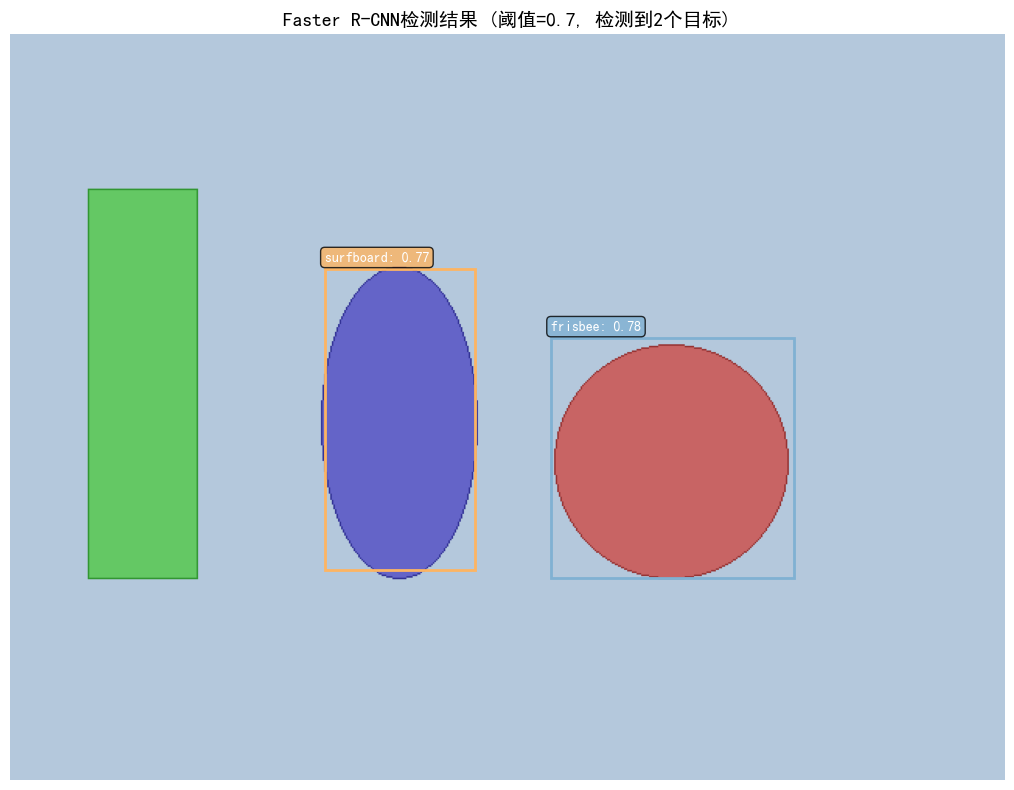

检测结果详情:
  frisbee: 置信度=0.780, 位置=[347,195,504,350]
  surfboard: 置信度=0.768, 位置=[202,151,298,344]


In [13]:
# 筛选高置信度的检测结果
def visualize_detection(img, prediction, score_threshold=0.5, coco_classes=COCO_CLASSES):
    """可视化目标检测结果"""
    boxes = prediction['boxes'].numpy()
    labels = prediction['labels'].numpy()
    scores = prediction['scores'].numpy()
    
    # 过滤低置信度
    mask = scores > score_threshold
    boxes = boxes[mask]
    labels = labels[mask]
    scores = scores[mask]
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(img)
    
    # 颜色映射
    colors = plt.cm.Set3(np.linspace(0, 1, len(coco_classes)))
    
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        class_name = coco_classes[label]
        color = colors[label % len(colors)]
        
        # 绘制边界框
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                linewidth=2, edgecolor=color[:3],
                                facecolor='none')
        ax.add_patch(rect)
        
        # 绘制标签
        ax.text(x1, y1 - 5, f'{class_name}: {score:.2f}',
               color='white', fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor=color[:3], alpha=0.8))
    
    ax.set_title(f'Faster R-CNN检测结果 (阈值={score_threshold}, 检测到{len(boxes)}个目标)', 
                fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # 打印检测结果
    if len(boxes) > 0:
        print("检测结果详情:")
        for box, label, score in zip(boxes, labels, scores):
            class_name = coco_classes[label]
            x1, y1, x2, y2 = box
            print(f"  {class_name}: 置信度={score:.3f}, 位置=[{x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}]")
    else:
        print(f"置信度>{score_threshold}的检测结果: 无")
        print("（示例图像为合成图像，可能无法检测到真实物体类别）")

# 可视化
visualize_detection(img_pil, prediction, score_threshold=0.7)


### 8.2 目标检测模型结构分析

让我们分析一下Faster R-CNN的模型结构和计算量：

In [14]:
# 分析Faster R-CNN模型结构
print("=== Faster R-CNN 模型结构 ===\n")

# 统计各部分的参数量
total_params = 0
backbone_params = 0
rpn_params = 0
head_params = 0

for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"{name:30s}: {params:>15,} 参数")
    total_params += params
    
print(f"{'='*48}")
print(f"{'总参数量':30s}: {total_params:>15,}")

# 模型的主要组件
print(f"\n=== 模型组件说明 ===")
print("1. backbone (ResNet-50 + FPN):  特征提取")
print("2. rpn (Region Proposal Network): 生成候选区域")
print("3. roi_heads (RoI Align + 分类/回归头): 分类和框精调")
print("4. transform (图像预处理): 输入标准化等")


=== Faster R-CNN 模型结构 ===

transform                     :               0 参数
backbone                      :      26,799,296 参数
rpn                           :         593,935 参数
roi_heads                     :      14,362,055 参数
总参数量                          :      41,755,286

=== 模型组件说明 ===
1. backbone (ResNet-50 + FPN):  特征提取
2. rpn (Region Proposal Network): 生成候选区域
3. roi_heads (RoI Align + 分类/回归头): 分类和框精调
4. transform (图像预处理): 输入标准化等


---

## 九、目标检测总结

### 9.1 关键概念回顾

```
目标检测核心流程:
  输入图像 → 特征提取(Backbone) → 候选区域生成(RPN/Anchor) 
  → 分类+回归 → NMS后处理 → 最终检测结果
```

### 9.2 知识图谱

| 模块 | 关键技术 | 公式/概念 |
|------|---------|----------|
| **边界框** | xyxy, xywh, cxcywh | 格式转换 |
| **锚框** | 多尺度+多宽高比 | 预设参考框 |
| **NMS** | 按置信度排序+IoU过滤 | 消除冗余检测 |
| **IoU** | 交集/并集 | 重叠度度量 |
| **mAP** | PR曲线下面积 | 综合评估指标 |
| **两阶段** | RPN → RoI | 高精度 |
| **单阶段** | 网格+锚框→直接预测 | 高速度 |
| **YOLO** | 网格划分+回归 | 检测即回归 |

---

## 十、练习题

### 练习1：基础概念
1. 请解释IoU的物理含义，为什么它在目标检测中如此重要？
2. NMS算法的输入是什么？为什么要进行NMS？如果不做NMS会怎样？
3. 两阶段检测器和单阶段检测器各有什么优缺点？

### 练习2：IoU计算
给定两个边界框：
- 框A：[10, 20, 80, 90]
- 框B：[50, 60, 120, 140]

请手算IoU值，然后用代码验证。

### 练习3：锚框分析
1. 如果特征图大小为 $13 \times 13$，每个位置3种尺度×3种宽高比，总共有多少个锚框？
2. 如果输入图像为 $416 \times 416$，每个锚框的基础大小为32，那么最小和最大的锚框分别是多大？

### 练习4：YOLO网格分析
1. YOLOv1中 $S=7, B=2, C=20$，总共输出多少个预测值？
2. 如果图像中有100个物体，但YOLOv1最多只能检测多少个？为什么？

### 练习5：实践任务（代码）
使用torchvision的Faster R-CNN模型对一张真实图片进行检测：
```python
# TODO: 读取真实图片
# TODO: 使用模型进行检测
# TODO: 可视化检测结果
# TODO: 尝试不同的置信度阈值，观察结果变化
```

---

> **本节小结**：
> - 目标检测 = 分类 + 定位，同时回答"是什么"和"在哪里"
> - 边界框有xyxy、xywh、cxcywh等表示格式
> - 锚框提供预设参考，降低学习难度
> - NMS消除冗余检测，IoU度量重叠程度
> - mAP是目标检测的核心评估指标
> - Faster R-CNN代表两阶段方法（精度优先），YOLO代表单阶段方法（速度优先）
> - YOLO将检测转化为回归问题，通过网格划分实现单次前向传播检测
>
> **下一节**：12.3 特征提取与迁移学习 — 学习如何利用预训练模型提升小数据集性能
